<a href="https://colab.research.google.com/github/huyle31251027190/BTVN-AI/blob/main/BTVN_AI_time_20_04_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install scikit-fuzzy matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.7 MB/s eta 0:00:00



   BÀI TẬP 1: HỆ THỐNG GIÁ TIỀN GRAB-BIKE

📋 TÌNH HUỐNG THỬ NGHIỆM:
   • Quãng đường : 5 km   (Medium)
   • Giao thông  : 75%    (High)
   • Mức cầu     : 80%    (High)
   • Thời tiết   : 7/10   (Bad)
   • Đánh giá    : 4.5 ⭐  (Good)
   • Đúng giờ    : 80%    (Early)

✅ KẾT QUẢ:
   💰 Giá đi xe    : 2.550  →  Cao (High)
   🏆 Điểm thưởng  : 2.545  →  Cao (High)


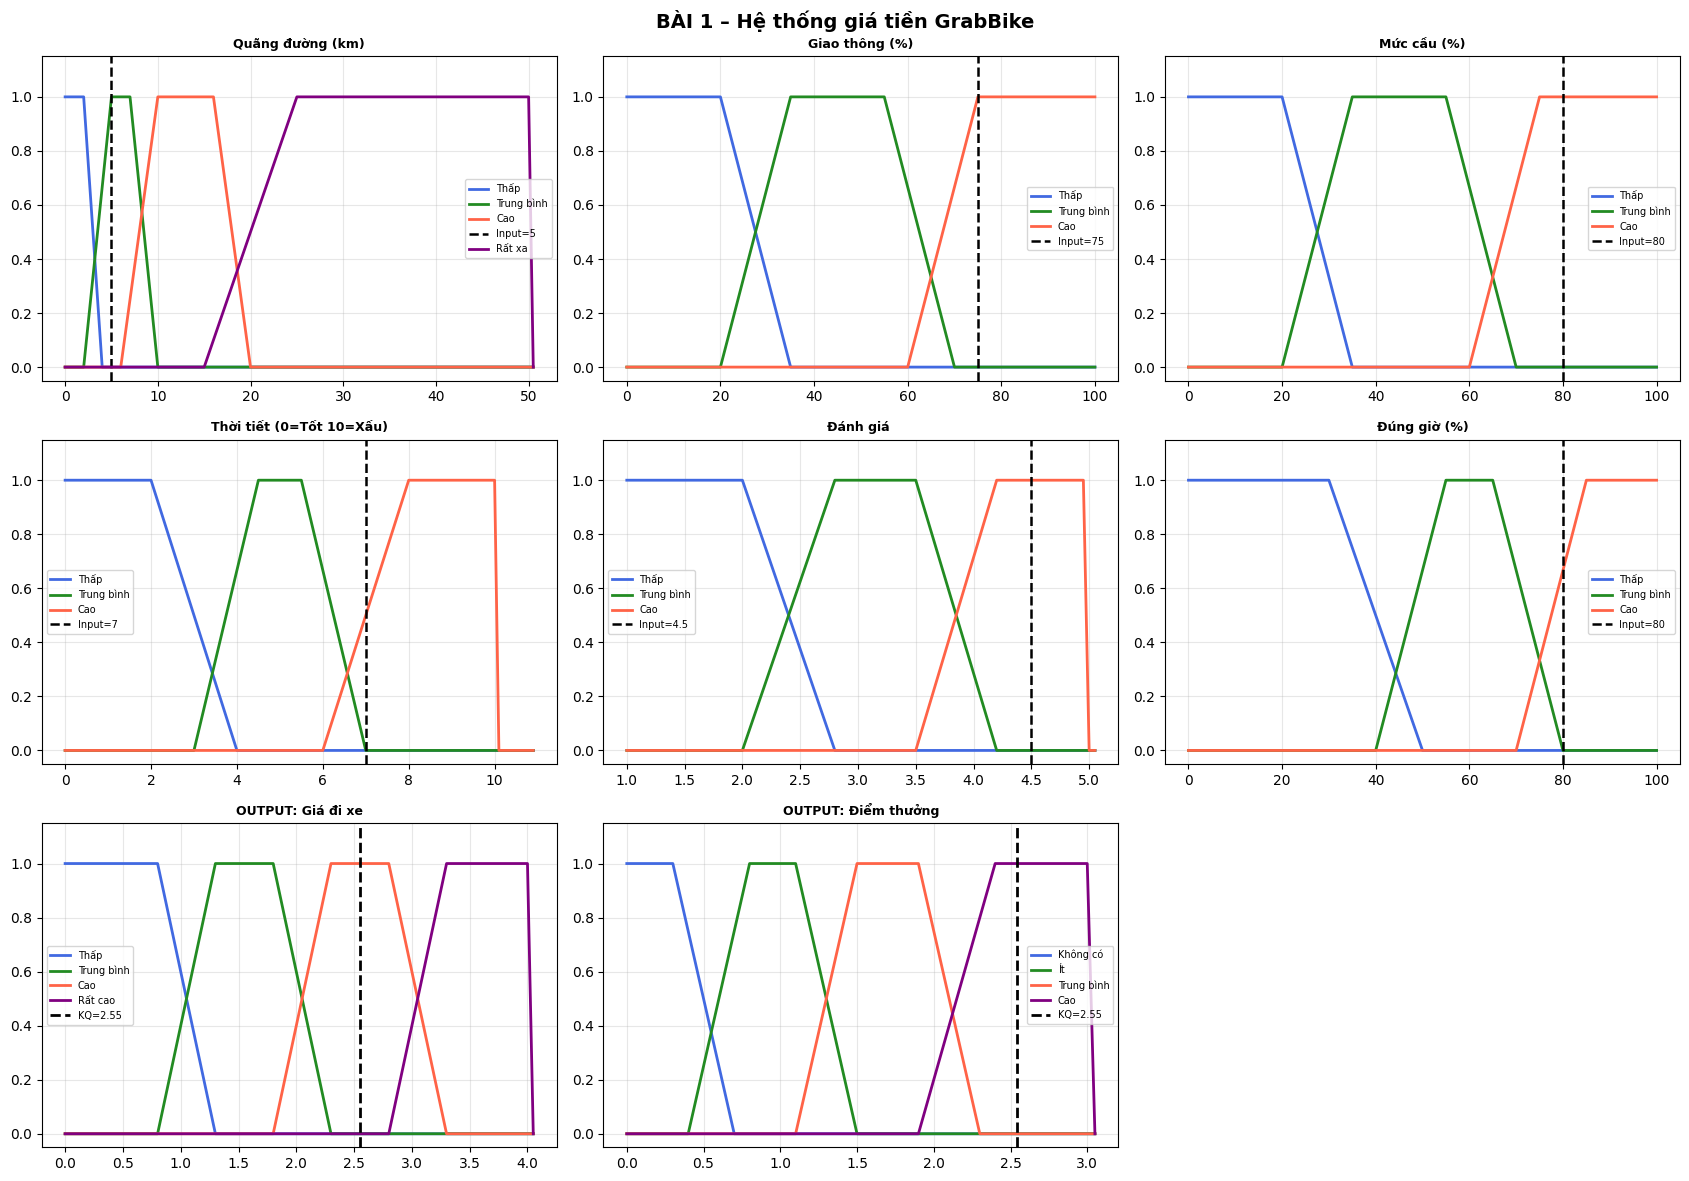


   BÀI TẬP 2: CHIẾN LƯỢC CHIẾT KHẤU SHOPEE

📋 TÌNH HUỐNG (theo đề bài):
   • Xếp hạng cửa hàng   : 4.3 ⭐   (Trung bình)
   • Khối lượng bán       : 250 đơn  (Trung bình)
   • Biên lợi nhuận       : 12%      (Thấp)
   • Sự kiện theo mùa     : 9/10     (Cao – Shopee 12.12)
   • Giảm giá đối thủ     : 35%      (Cao)

✅ KẾT QUẢ:
   🏷️  Chiết khấu đề xuất : 52.79%  →  Rất cao (40–70%)
   📌 Sự kiện lớn + Đối thủ mạnh → Cần chiết khấu cao
      để giữ vị thế cạnh tranh trên Shopee.


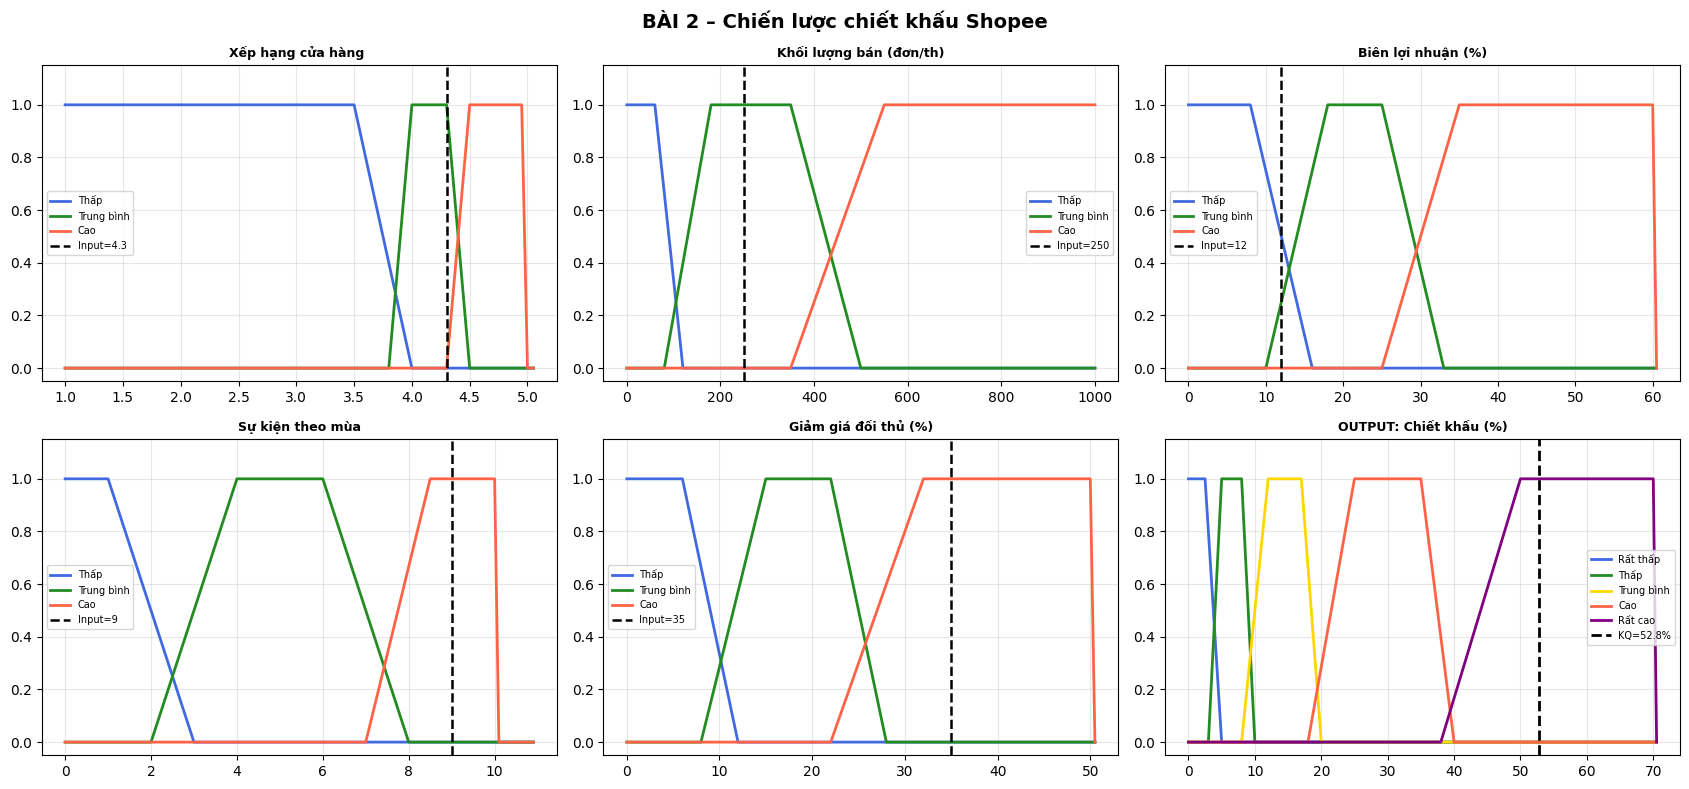


   BÀI TẬP 3: BÁN HÀNG ĐẶC BIỆT SHOPEE

📋 TÌNH HUỐNG: Đồng hồ xa xỉ thủ công
   • Nhu cầu sản phẩm  : 80%   (Cao)
   • Áp lực đối thủ    : 50%   (Trung bình)
   • Uy tín cửa hàng   : 4.2 ⭐ (Trung bình)
   • Biên lợi nhuận    : 50%   (Cao)
   • Nhu cầu theo mùa  : 9/10  (Cao – Shopee 11.11)

✅ KẾT QUẢ:
   🏷️  Mức giảm giá đề xuất : 15.21%  →  Trung bình (10–20%)
   📌 Biên lợi nhuận cao + Sự kiện 11.11
      → Chiết khấu trung bình (~15–25%) là tối ưu.


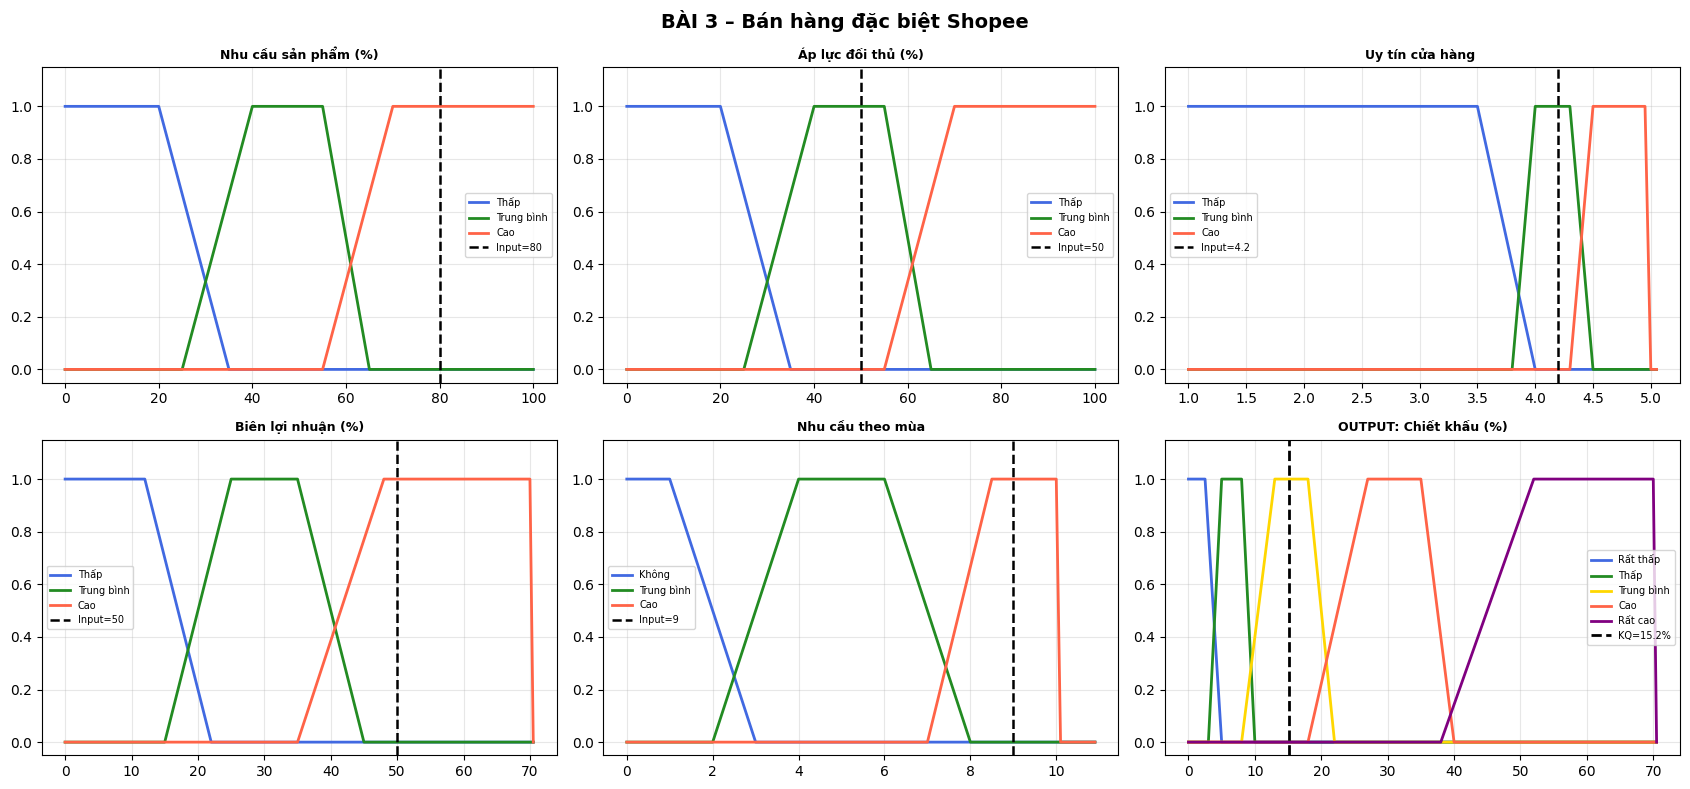


   BÀI TẬP 4: TỐI ƯU HÓA THỜI GIAN GIAO HÀNG

📋 TÌNH HUỐNG (theo đề bài):
   • Mật độ đơn hàng   : 85%  (Cao)
   • Mức độ khẩn cấp   : 50%  (Trung bình)
   • Tải trọng tài xế  : 15%  (Thấp)
   • Điều kiện giao thông: 50% (Trung bình)
   • Lợi nhuận/giao    : 50%  (Trung bình)

✅ KẾT QUẢ:
   📦 Số đơn kết hợp  : 7.85  →  Nhiều (6+ đơn)
   🎯 Mức ưu tiên     : 1.50   →  Trung bình
   📌 Mật độ cao + Tải thấp → Kết hợp nhiều đơn cùng lúc
      Khẩn cấp trung bình → Ưu tiên giao hàng ở mức vừa


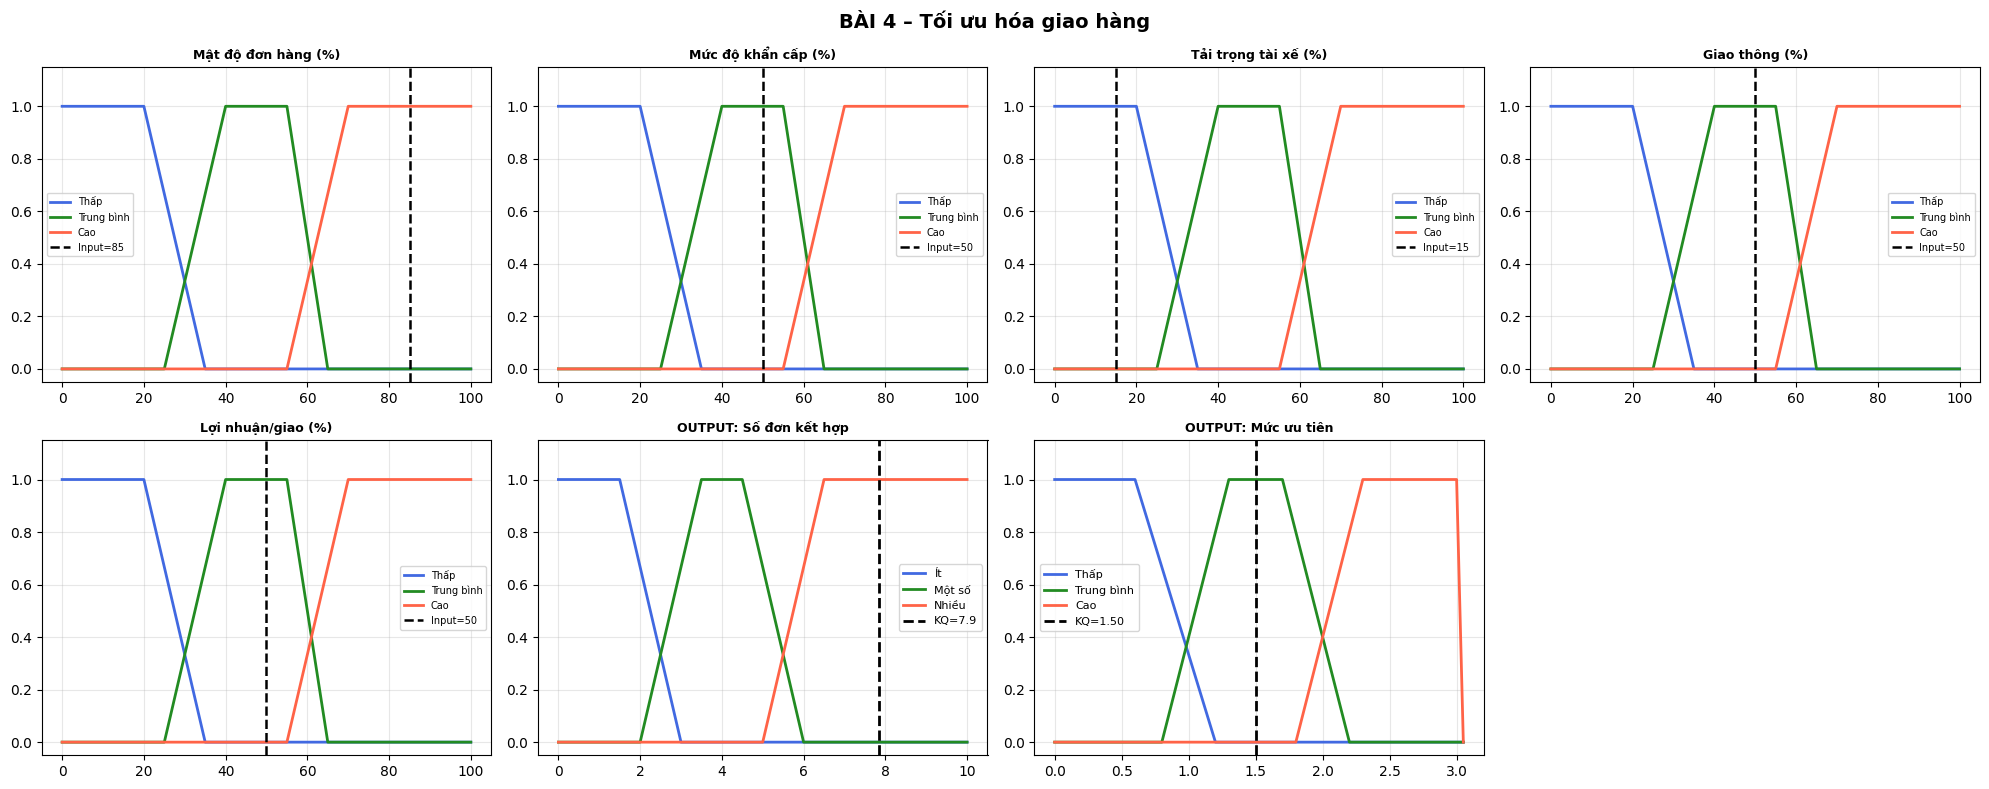

In [10]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image

#   HÀM TIỆN ÍCH
def plot_mf_3(ax, universe, mf_list, title, x_mark=None, colors=('royalblue','forestgreen','tomato')):
    """Vẽ 3 hàm thành viên (Thấp / Trung bình / Cao) trên 1 axes."""
    labels = ['Thấp', 'Trung bình', 'Cao']
    for params, col, lbl in zip(mf_list, colors, labels):
        ax.plot(universe, fuzz.trapmf(universe, params), color=col, linewidth=2, label=lbl)
    if x_mark is not None:
        ax.axvline(x=x_mark, color='black', linestyle='--', linewidth=1.8, label=f'Input={x_mark}')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_ylim(-0.05, 1.15)
    ax.grid(True, alpha=0.3)


# ══════════════════════════════════════════════════════════════
#   BÀI TẬP 1: HỆ THỐNG GIÁ TIỀN GRAB-BIKE
# ══════════════════════════════════════════════════════════════

def bai1_grabbike():
    print("\n" + "=" * 65)
    print("   BÀI TẬP 1: HỆ THỐNG GIÁ TIỀN GRAB-BIKE")
    print("=" * 65)

    # ── Biến đầu vào ───────────────────────────────────────────
    distance    = ctrl.Antecedent(np.arange(0, 51, 0.5),   'distance')
    traffic     = ctrl.Antecedent(np.arange(0, 101, 1),    'traffic')
    demand      = ctrl.Antecedent(np.arange(0, 101, 1),    'demand')
    weather     = ctrl.Antecedent(np.arange(0, 11, 0.1),   'weather')
    rating      = ctrl.Antecedent(np.arange(1.0, 5.1, 0.05), 'rating')
    punctuality = ctrl.Antecedent(np.arange(0, 101, 1),    'punctuality')

    # ── Biến đầu ra ────────────────────────────────────────────
    price = ctrl.Consequent(np.arange(0, 4.1, 0.05), 'price')
    bonus = ctrl.Consequent(np.arange(0, 3.1, 0.05), 'bonus')

    # ── Hàm thành viên – đầu vào ───────────────────────────────
    distance['short']     = fuzz.trapmf(distance.universe, [0, 0, 2, 4])
    distance['medium']    = fuzz.trapmf(distance.universe, [2, 5, 7, 10])
    distance['long']      = fuzz.trapmf(distance.universe, [6, 10, 16, 20])
    distance['very_long'] = fuzz.trapmf(distance.universe, [15, 25, 50, 50])

    traffic['low']    = fuzz.trapmf(traffic.universe, [0, 0, 20, 35])
    traffic['medium'] = fuzz.trapmf(traffic.universe, [20, 35, 55, 70])
    traffic['high']   = fuzz.trapmf(traffic.universe, [60, 75, 100, 100])

    demand['low']    = fuzz.trapmf(demand.universe, [0, 0, 20, 35])
    demand['medium'] = fuzz.trapmf(demand.universe, [20, 35, 55, 70])
    demand['high']   = fuzz.trapmf(demand.universe, [60, 75, 100, 100])

    weather['good']     = fuzz.trapmf(weather.universe, [0, 0, 2, 4])
    weather['moderate'] = fuzz.trapmf(weather.universe, [3, 4.5, 5.5, 7])
    weather['bad']      = fuzz.trapmf(weather.universe, [6, 8, 10, 10])

    rating['poor']    = fuzz.trapmf(rating.universe, [1.0, 1.0, 2.0, 2.8])
    rating['average'] = fuzz.trapmf(rating.universe, [2.0, 2.8, 3.5, 4.2])
    rating['good']    = fuzz.trapmf(rating.universe, [3.5, 4.2, 5.0, 5.0])

    punctuality['late']    = fuzz.trapmf(punctuality.universe, [0, 0, 30, 50])
    punctuality['on_time'] = fuzz.trapmf(punctuality.universe, [40, 55, 65, 80])
    punctuality['early']   = fuzz.trapmf(punctuality.universe, [70, 85, 100, 100])

    # ── Hàm thành viên – đầu ra ────────────────────────────────
    price['low']       = fuzz.trapmf(price.universe, [0, 0, 0.8, 1.3])
    price['medium']    = fuzz.trapmf(price.universe, [0.8, 1.3, 1.8, 2.3])
    price['high']      = fuzz.trapmf(price.universe, [1.8, 2.3, 2.8, 3.3])
    price['very_high'] = fuzz.trapmf(price.universe, [2.8, 3.3, 4.0, 4.0])

    bonus['none']     = fuzz.trapmf(bonus.universe, [0, 0, 0.3, 0.7])
    bonus['few']      = fuzz.trapmf(bonus.universe, [0.4, 0.8, 1.1, 1.5])
    bonus['moderate'] = fuzz.trapmf(bonus.universe, [1.1, 1.5, 1.9, 2.3])
    bonus['high']     = fuzz.trapmf(bonus.universe, [1.9, 2.4, 3.0, 3.0])

    # ── Luật mờ (20 luật) ──────────────────────────────────────
    rules = [
        # Luật giá (1–10)
        ctrl.Rule(distance['short']     & traffic['low']    & demand['low'],            price['low']),
        ctrl.Rule(distance['short']     & traffic['medium'] & demand['high'],            price['medium']),
        ctrl.Rule(distance['medium']    & traffic['high']   & demand['high'],            price['high']),
        ctrl.Rule(distance['long']      & traffic['medium'] & weather['good'],           price['medium']),
        ctrl.Rule(distance['long']      & traffic['high']   & weather['bad'],            price['very_high']),
        ctrl.Rule(distance['very_long'] & traffic['high']   & demand['high'],            price['very_high']),
        ctrl.Rule(distance['medium']    & traffic['low']    & demand['low'],             price['medium']),
        ctrl.Rule(distance['short']     & traffic['high']   & weather['bad'],            price['high']),
        ctrl.Rule(distance['very_long'] & weather['bad'],                                price['very_high']),
        ctrl.Rule(distance['medium']    & traffic['medium'] & weather['moderate'],       price['medium']),
        # Luật điểm thưởng (11–20)
        ctrl.Rule(rating['good']    & punctuality['early'],                              bonus['high']),
        ctrl.Rule(rating['average'] & punctuality['on_time'],                            bonus['moderate']),
        ctrl.Rule(rating['poor']    & punctuality['late'],                               bonus['none']),
        ctrl.Rule(distance['long']  & traffic['high']   & punctuality['on_time'],        bonus['high']),
        ctrl.Rule(distance['medium']& traffic['medium'] & rating['good'],                bonus['moderate']),
        ctrl.Rule(rating['poor']    & punctuality['on_time'],                            bonus['few']),
        ctrl.Rule(distance['very_long'] & weather['bad']  & rating['good'],             bonus['high']),
        ctrl.Rule(distance['short'] & rating['average']   & punctuality['on_time'],     bonus['few']),
        ctrl.Rule(distance['long']  & traffic['high']     & punctuality['late'],         bonus['few']),
        ctrl.Rule(distance['medium']& weather['moderate'] & rating['good'],              bonus['moderate']),
    ]

    system = ctrl.ControlSystem(rules)
    sim    = ctrl.ControlSystemSimulation(system)

    # ── Tình huống thử nghiệm ──────────────────────────────────
    print("\n📋 TÌNH HUỐNG THỬ NGHIỆM:")
    print("   • Quãng đường : 5 km   (Medium)")
    print("   • Giao thông  : 75%    (High)")
    print("   • Mức cầu     : 80%    (High)")
    print("   • Thời tiết   : 7/10   (Bad)")
    print("   • Đánh giá    : 4.5 ⭐  (Good)")
    print("   • Đúng giờ    : 80%    (Early)")

    sim.input['distance']    = 5
    sim.input['traffic']     = 75
    sim.input['demand']      = 80
    sim.input['weather']     = 7
    sim.input['rating']      = 4.5
    sim.input['punctuality'] = 80
    sim.compute()

    p = sim.output['price']
    b = sim.output['bonus']

    price_label = ("Thấp (Low)"       if p < 1.0 else
                   "Trung bình (Med)" if p < 2.0 else
                   "Cao (High)"       if p < 3.0 else
                   "Rất cao (V.High)")
    bonus_label = ("Không có (None)"    if b < 0.6 else
                   "Ít (Few)"           if b < 1.3 else
                   "Trung bình (Mod)"   if b < 2.1 else
                   "Cao (High)")

    print(f"\n✅ KẾT QUẢ:")
    print(f"   💰 Giá đi xe    : {p:.3f}  →  {price_label}")
    print(f"   🏆 Điểm thưởng  : {b:.3f}  →  {bonus_label}")

    # ── Đồ thị ─────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 3, figsize=(17, 12))
    fig.suptitle('BÀI 1 – Hệ thống giá tiền GrabBike', fontsize=14, fontweight='bold')

    plot_mf_3(axes[0,0], distance.universe,
              [[0,0,2,4],[2,5,7,10],[6,10,16,20]], 'Quãng đường (km)', 5)
    # Thêm Very Long riêng
    axes[0,0].plot(distance.universe,
                   fuzz.trapmf(distance.universe, [15,25,50,50]),
                   color='purple', linewidth=2, label='Rất xa')
    axes[0,0].legend(fontsize=7)

    plot_mf_3(axes[0,1], traffic.universe,
              [[0,0,20,35],[20,35,55,70],[60,75,100,100]], 'Giao thông (%)', 75)
    plot_mf_3(axes[0,2], demand.universe,
              [[0,0,20,35],[20,35,55,70],[60,75,100,100]], 'Mức cầu (%)', 80)
    plot_mf_3(axes[1,0], weather.universe,
              [[0,0,2,4],[3,4.5,5.5,7],[6,8,10,10]], 'Thời tiết (0=Tốt 10=Xấu)', 7)
    plot_mf_3(axes[1,1], rating.universe,
              [[1,1,2,2.8],[2,2.8,3.5,4.2],[3.5,4.2,5,5]], 'Đánh giá ', 4.5)
    plot_mf_3(axes[1,2], punctuality.universe,
              [[0,0,30,50],[40,55,65,80],[70,85,100,100]], 'Đúng giờ (%)', 80)

    # Output – Giá
    ax = axes[2, 0]
    for mf_vals, col, lbl in [
        ([0,0,0.8,1.3],   'royalblue',   'Thấp'),
        ([0.8,1.3,1.8,2.3],'forestgreen','Trung bình'),
        ([1.8,2.3,2.8,3.3],'tomato',     'Cao'),
        ([2.8,3.3,4,4],   'purple',      'Rất cao'),
    ]:
        ax.plot(price.universe, fuzz.trapmf(price.universe, mf_vals), color=col, linewidth=2, label=lbl)
    ax.axvline(x=p, color='black', linestyle='--', linewidth=2, label=f'KQ={p:.2f}')
    ax.set_title('OUTPUT: Giá đi xe', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.15); ax.grid(True, alpha=0.3)

    # Output – Điểm thưởng
    ax = axes[2, 1]
    for mf_vals, col, lbl in [
        ([0,0,0.3,0.7],   'royalblue',   'Không có'),
        ([0.4,0.8,1.1,1.5],'forestgreen','Ít'),
        ([1.1,1.5,1.9,2.3],'tomato',     'Trung bình'),
        ([1.9,2.4,3,3],   'purple',      'Cao'),
    ]:
        ax.plot(bonus.universe, fuzz.trapmf(bonus.universe, mf_vals), color=col, linewidth=2, label=lbl)
    ax.axvline(x=b, color='black', linestyle='--', linewidth=2, label=f'KQ={b:.2f}')
    ax.set_title('OUTPUT: Điểm thưởng', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.15); ax.grid(True, alpha=0.3)

    axes[2, 2].axis('off')
    plt.tight_layout()
    plt.savefig('bai1_grabbike.png', dpi=120, bbox_inches='tight')
    plt.show()


# ══════════════════════════════════════════════════════════════
#   BÀI TẬP 2: CHIẾN LƯỢC CHIẾT KHẤU SHOPEE
# ══════════════════════════════════════════════════════════════

def bai2_shopee_discount():
    print("\n" + "=" * 65)
    print("   BÀI TẬP 2: CHIẾN LƯỢC CHIẾT KHẤU SHOPEE")
    print("=" * 65)

    # ── Biến đầu vào ───────────────────────────────────────────
    store_rating        = ctrl.Antecedent(np.arange(1.0, 5.1, 0.05), 'store_rating')
    sales_volume        = ctrl.Antecedent(np.arange(0, 1001, 5),     'sales_volume')
    profit_margin       = ctrl.Antecedent(np.arange(0, 61, 0.5),     'profit_margin')
    seasonal_event      = ctrl.Antecedent(np.arange(0, 11, 0.1),     'seasonal_event')
    competitor_discount = ctrl.Antecedent(np.arange(0, 51, 0.5),     'competitor_discount')

    # ── Biến đầu ra ────────────────────────────────────────────
    discount = ctrl.Consequent(np.arange(0, 71, 0.5), 'discount')

    # ── Hàm thành viên – đầu vào ───────────────────────────────
    store_rating['low']    = fuzz.trapmf(store_rating.universe, [1.0, 1.0, 3.5, 4.0])
    store_rating['medium'] = fuzz.trapmf(store_rating.universe, [3.8, 4.0, 4.3, 4.5])
    store_rating['high']   = fuzz.trapmf(store_rating.universe, [4.3, 4.5, 5.0, 5.0])

    sales_volume['low']    = fuzz.trapmf(sales_volume.universe, [0, 0, 60, 120])
    sales_volume['medium'] = fuzz.trapmf(sales_volume.universe, [80, 180, 350, 500])
    sales_volume['high']   = fuzz.trapmf(sales_volume.universe, [350, 550, 1000, 1000])

    profit_margin['low']    = fuzz.trapmf(profit_margin.universe, [0, 0, 8, 16])
    profit_margin['medium'] = fuzz.trapmf(profit_margin.universe, [10, 18, 25, 33])
    profit_margin['high']   = fuzz.trapmf(profit_margin.universe, [25, 35, 60, 60])

    seasonal_event['none']     = fuzz.trapmf(seasonal_event.universe, [0, 0, 1, 3])
    seasonal_event['moderate'] = fuzz.trapmf(seasonal_event.universe, [2, 4, 6, 8])
    seasonal_event['high']     = fuzz.trapmf(seasonal_event.universe, [7, 8.5, 10, 10])

    competitor_discount['low']    = fuzz.trapmf(competitor_discount.universe, [0, 0, 6, 12])
    competitor_discount['medium'] = fuzz.trapmf(competitor_discount.universe, [8, 15, 22, 28])
    competitor_discount['high']   = fuzz.trapmf(competitor_discount.universe, [22, 32, 50, 50])

    # ── Hàm thành viên – đầu ra ────────────────────────────────
    discount['very_low'] = fuzz.trapmf(discount.universe, [0, 0, 2.5, 5])
    discount['low']      = fuzz.trapmf(discount.universe, [3, 5, 8, 10])
    discount['medium']   = fuzz.trapmf(discount.universe, [8, 12, 17, 20])
    discount['high']     = fuzz.trapmf(discount.universe, [18, 25, 35, 40])
    discount['very_high']= fuzz.trapmf(discount.universe, [38, 50, 70, 70])

    # ── Luật mờ (7 luật + 1 luật dự phòng) ────────────────────
    rules = [
        ctrl.Rule(store_rating['high']   & sales_volume['high']   & profit_margin['high'],
                  discount['very_low']),                                                     # Luật 1
        ctrl.Rule(store_rating['low']    & sales_volume['low']    & profit_margin['high'],
                  discount['high']),                                                         # Luật 2
        ctrl.Rule(seasonal_event['high'] & competitor_discount['high'],
                  discount['very_high']),                                                    # Luật 3
        ctrl.Rule(store_rating['medium'] & sales_volume['medium'] & profit_margin['medium'],
                  discount['medium']),                                                       # Luật 4
        ctrl.Rule(competitor_discount['low'] & profit_margin['low'] & sales_volume['high'],
                  discount['very_low']),                                                     # Luật 5
        ctrl.Rule(store_rating['low']    & seasonal_event['none'],
                  discount['medium']),                                                       # Luật 6
        ctrl.Rule(sales_volume['low']    & profit_margin['low'],
                  discount['very_high']),                                                    # Luật 7
        # Luật dự phòng: sự kiện cao + đối thủ trung bình
        ctrl.Rule(seasonal_event['high'] & competitor_discount['medium'],
                  discount['high']),
    ]

    system = ctrl.ControlSystem(rules)
    sim    = ctrl.ControlSystemSimulation(system)

    # ── Tình huống theo đề bài ─────────────────────────────────
    print("\n📋 TÌNH HUỐNG (theo đề bài):")
    print("   • Xếp hạng cửa hàng   : 4.3 ⭐   (Trung bình)")
    print("   • Khối lượng bán       : 250 đơn  (Trung bình)")
    print("   • Biên lợi nhuận       : 12%      (Thấp)")
    print("   • Sự kiện theo mùa     : 9/10     (Cao – Shopee 12.12)")
    print("   • Giảm giá đối thủ     : 35%      (Cao)")

    sim.input['store_rating']        = 4.3
    sim.input['sales_volume']        = 250
    sim.input['profit_margin']       = 12
    sim.input['seasonal_event']      = 9
    sim.input['competitor_discount'] = 35
    sim.compute()

    d = sim.output['discount']
    d_label = ("Rất thấp (0–5%)"   if d <  5 else
               "Thấp (5–10%)"      if d < 10 else
               "Trung bình (10–20%)" if d < 20 else
               "Cao (20–40%)"      if d < 40 else
               "Rất cao (40–70%)")

    print(f"\n✅ KẾT QUẢ:")
    print(f"   🏷️  Chiết khấu đề xuất : {d:.2f}%  →  {d_label}")
    print("   📌 Sự kiện lớn + Đối thủ mạnh → Cần chiết khấu cao")
    print("      để giữ vị thế cạnh tranh trên Shopee.")

    # ── Đồ thị ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(17, 8))
    fig.suptitle('BÀI 2 – Chiến lược chiết khấu Shopee', fontsize=14, fontweight='bold')

    plot_mf_3(axes[0,0], store_rating.universe,
              [[1,1,3.5,4],[3.8,4,4.3,4.5],[4.3,4.5,5,5]], 'Xếp hạng cửa hàng ', 4.3)
    plot_mf_3(axes[0,1], sales_volume.universe,
              [[0,0,60,120],[80,180,350,500],[350,550,1000,1000]], 'Khối lượng bán (đơn/th)', 250)
    plot_mf_3(axes[0,2], profit_margin.universe,
              [[0,0,8,16],[10,18,25,33],[25,35,60,60]], 'Biên lợi nhuận (%)', 12)
    plot_mf_3(axes[1,0], seasonal_event.universe,
              [[0,0,1,3],[2,4,6,8],[7,8.5,10,10]], 'Sự kiện theo mùa', 9,
              colors=('royalblue','forestgreen','tomato'))
    plot_mf_3(axes[1,1], competitor_discount.universe,
              [[0,0,6,12],[8,15,22,28],[22,32,50,50]], 'Giảm giá đối thủ (%)', 35)

    ax = axes[1, 2]
    for mf_vals, col, lbl in [
        ([0,0,2.5,5],   'royalblue',    'Rất thấp'),
        ([3,5,8,10],    'forestgreen',  'Thấp'),
        ([8,12,17,20],  'gold',         'Trung bình'),
        ([18,25,35,40], 'tomato',       'Cao'),
        ([38,50,70,70], 'purple',       'Rất cao'),
    ]:
        ax.plot(discount.universe, fuzz.trapmf(discount.universe, mf_vals),
                color=col, linewidth=2, label=lbl)
    ax.axvline(x=d, color='black', linestyle='--', linewidth=2, label=f'KQ={d:.1f}%')
    ax.set_title('OUTPUT: Chiết khấu (%)', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.15); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('bai2_shopee_discount.png', dpi=120, bbox_inches='tight')
    plt.show()


# ══════════════════════════════════════════════════════════════
#   BÀI TẬP 3: CHIẾN LƯỢC BÁN HÀNG ĐẶC BIỆT SHOPEE
# ══════════════════════════════════════════════════════════════

def bai3_shopee_special():
    print("\n" + "=" * 65)
    print("   BÀI TẬP 3: BÁN HÀNG ĐẶC BIỆT SHOPEE")
    print("=" * 65)

    # ── Biến đầu vào ───────────────────────────────────────────
    product_demand      = ctrl.Antecedent(np.arange(0, 101, 1),      'product_demand')
    competitor_pressure = ctrl.Antecedent(np.arange(0, 101, 1),      'competitor_pressure')
    store_reputation    = ctrl.Antecedent(np.arange(1.0, 5.1, 0.05), 'store_reputation')
    profit_margin       = ctrl.Antecedent(np.arange(0, 71, 0.5),     'profit_margin')
    seasonal_demand     = ctrl.Antecedent(np.arange(0, 11, 0.1),     'seasonal_demand')

    # ── Biến đầu ra ────────────────────────────────────────────
    discount_pct = ctrl.Consequent(np.arange(0, 71, 0.5), 'discount_pct')

    # ── Hàm thành viên – đầu vào ───────────────────────────────
    product_demand['low']    = fuzz.trapmf(product_demand.universe,      [0, 0, 20, 35])
    product_demand['medium'] = fuzz.trapmf(product_demand.universe,      [25, 40, 55, 65])
    product_demand['high']   = fuzz.trapmf(product_demand.universe,      [55, 70, 100, 100])

    competitor_pressure['low']    = fuzz.trapmf(competitor_pressure.universe, [0, 0, 20, 35])
    competitor_pressure['medium'] = fuzz.trapmf(competitor_pressure.universe, [25, 40, 55, 65])
    competitor_pressure['high']   = fuzz.trapmf(competitor_pressure.universe, [55, 70, 100, 100])

    store_reputation['low']    = fuzz.trapmf(store_reputation.universe,  [1.0, 1.0, 3.5, 4.0])
    store_reputation['medium'] = fuzz.trapmf(store_reputation.universe,  [3.8, 4.0, 4.3, 4.5])
    store_reputation['high']   = fuzz.trapmf(store_reputation.universe,  [4.3, 4.5, 5.0, 5.0])

    profit_margin['low']    = fuzz.trapmf(profit_margin.universe, [0, 0, 12, 22])
    profit_margin['medium'] = fuzz.trapmf(profit_margin.universe, [15, 25, 35, 45])
    profit_margin['high']   = fuzz.trapmf(profit_margin.universe, [35, 48, 70, 70])

    seasonal_demand['none']   = fuzz.trapmf(seasonal_demand.universe, [0, 0, 1, 3])
    seasonal_demand['medium'] = fuzz.trapmf(seasonal_demand.universe, [2, 4, 6, 8])
    seasonal_demand['high']   = fuzz.trapmf(seasonal_demand.universe, [7, 8.5, 10, 10])

    # ── Hàm thành viên – đầu ra ────────────────────────────────
    discount_pct['very_low'] = fuzz.trapmf(discount_pct.universe, [0, 0, 2.5, 5])
    discount_pct['low']      = fuzz.trapmf(discount_pct.universe, [3, 5, 8, 10])
    discount_pct['medium']   = fuzz.trapmf(discount_pct.universe, [8, 13, 18, 22])
    discount_pct['high']     = fuzz.trapmf(discount_pct.universe, [18, 27, 35, 40])
    discount_pct['very_high']= fuzz.trapmf(discount_pct.universe, [38, 52, 70, 70])

    # ── Luật mờ (7 luật theo đề + 2 luật bổ sung) ─────────────
    rules = [
        # Luật 1: Nhu cầu cao + đối thủ thấp + lợi nhuận thấp → Rất thấp
        ctrl.Rule(product_demand['high'] & competitor_pressure['low'] & profit_margin['low'],
                  discount_pct['very_low']),
        # Luật 2: Nhu cầu thấp + đối thủ cao + lợi nhuận cao → Cao
        ctrl.Rule(product_demand['low']  & competitor_pressure['high'] & profit_margin['high'],
                  discount_pct['high']),
        # Luật 3: Uy tín cao + lợi nhuận TB + mùa cao → TB
        ctrl.Rule(store_reputation['high'] & profit_margin['medium'] & seasonal_demand['high'],
                  discount_pct['medium']),
        # Luật 4: Đối thủ cao + mùa cao + lợi nhuận cao → Rất cao
        ctrl.Rule(competitor_pressure['high'] & seasonal_demand['high'] & profit_margin['high'],
                  discount_pct['very_high']),
        # Luật 5: Uy tín thấp + nhu cầu TB + lợi nhuận thấp → TB
        ctrl.Rule(store_reputation['low'] & product_demand['medium'] & profit_margin['low'],
                  discount_pct['medium']),
        # Luật 6: Nhu cầu cao + không có mùa + đối thủ thấp → Rất thấp
        ctrl.Rule(product_demand['high'] & seasonal_demand['none'] & competitor_pressure['low'],
                  discount_pct['very_low']),
        # Luật 7: Lợi nhuận cao + đối thủ TB + mùa TB → TB
        ctrl.Rule(profit_margin['high'] & competitor_pressure['medium'] & seasonal_demand['medium'],
                  discount_pct['medium']),
        # Luật 8 (bổ sung): Lợi nhuận cao + mùa cao + đối thủ TB → Trung bình
        ctrl.Rule(profit_margin['high'] & seasonal_demand['high'] & competitor_pressure['medium'],
                  discount_pct['medium']),
        # Luật 9 (bổ sung): Nhu cầu cao + mùa cao + lợi nhuận cao → Trung bình
        ctrl.Rule(product_demand['high'] & seasonal_demand['high'] & profit_margin['high'],
                  discount_pct['medium']),
    ]

    system = ctrl.ControlSystem(rules)
    sim    = ctrl.ControlSystemSimulation(system)

    # ── Tình huống: Đồng hồ xa xỉ (theo đề bài) ───────────────
    print("\n📋 TÌNH HUỐNG: Đồng hồ xa xỉ thủ công")
    print("   • Nhu cầu sản phẩm  : 80%   (Cao)")
    print("   • Áp lực đối thủ    : 50%   (Trung bình)")
    print("   • Uy tín cửa hàng   : 4.2 ⭐ (Trung bình)")
    print("   • Biên lợi nhuận    : 50%   (Cao)")
    print("   • Nhu cầu theo mùa  : 9/10  (Cao – Shopee 11.11)")

    sim.input['product_demand']      = 80
    sim.input['competitor_pressure'] = 50
    sim.input['store_reputation']    = 4.2
    sim.input['profit_margin']       = 50
    sim.input['seasonal_demand']     = 9
    sim.compute()

    d3 = sim.output['discount_pct']
    d3_label = ("Rất thấp (0–5%)"    if d3 <  5 else
                "Thấp (5–10%)"       if d3 < 10 else
                "Trung bình (10–20%)"if d3 < 20 else
                "Cao (20–40%)"       if d3 < 40 else
                "Rất cao (40–70%)")

    print(f"\n✅ KẾT QUẢ:")
    print(f"   🏷️  Mức giảm giá đề xuất : {d3:.2f}%  →  {d3_label}")
    print("   📌 Biên lợi nhuận cao + Sự kiện 11.11")
    print("      → Chiết khấu trung bình (~15–25%) là tối ưu.")

    # ── Đồ thị ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(17, 8))
    fig.suptitle('BÀI 3 – Bán hàng đặc biệt Shopee', fontsize=14, fontweight='bold')

    plot_mf_3(axes[0,0], product_demand.universe,
              [[0,0,20,35],[25,40,55,65],[55,70,100,100]], 'Nhu cầu sản phẩm (%)', 80)
    plot_mf_3(axes[0,1], competitor_pressure.universe,
              [[0,0,20,35],[25,40,55,65],[55,70,100,100]], 'Áp lực đối thủ (%)', 50)
    plot_mf_3(axes[0,2], store_reputation.universe,
              [[1,1,3.5,4],[3.8,4,4.3,4.5],[4.3,4.5,5,5]], 'Uy tín cửa hàng ', 4.2)
    plot_mf_3(axes[1,0], profit_margin.universe,
              [[0,0,12,22],[15,25,35,45],[35,48,70,70]], 'Biên lợi nhuận (%)', 50)

    ax = axes[1, 1]
    ax.plot(seasonal_demand.universe, fuzz.trapmf(seasonal_demand.universe,[0,0,1,3]),
            color='royalblue',  linewidth=2, label='Không')
    ax.plot(seasonal_demand.universe, fuzz.trapmf(seasonal_demand.universe,[2,4,6,8]),
            color='forestgreen',linewidth=2, label='Trung bình')
    ax.plot(seasonal_demand.universe, fuzz.trapmf(seasonal_demand.universe,[7,8.5,10,10]),
            color='tomato',     linewidth=2, label='Cao')
    ax.axvline(x=9, color='black', linestyle='--', linewidth=1.8, label='Input=9')
    ax.set_title('Nhu cầu theo mùa', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.15); ax.grid(True, alpha=0.3)

    ax = axes[1, 2]
    for mf_vals, col, lbl in [
        ([0,0,2.5,5],   'royalblue',  'Rất thấp'),
        ([3,5,8,10],    'forestgreen','Thấp'),
        ([8,13,18,22],  'gold',       'Trung bình'),
        ([18,27,35,40], 'tomato',     'Cao'),
        ([38,52,70,70], 'purple',     'Rất cao'),
    ]:
        ax.plot(discount_pct.universe,
                fuzz.trapmf(discount_pct.universe, mf_vals),
                color=col, linewidth=2, label=lbl)
    ax.axvline(x=d3, color='black', linestyle='--', linewidth=2, label=f'KQ={d3:.1f}%')
    ax.set_title('OUTPUT: Chiết khấu (%)', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.15); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('bai3_shopee_special.png', dpi=120, bbox_inches='tight')
    plt.show()


# ══════════════════════════════════════════════════════════════
#   BÀI TẬP 4: TỐI ƯU HÓA THỜI GIAN GIAO HÀNG
# ══════════════════════════════════════════════════════════════

def bai4_delivery_optimization():
    print("\n" + "=" * 65)
    print("   BÀI TẬP 4: TỐI ƯU HÓA THỜI GIAN GIAO HÀNG")
    print("=" * 65)

    # ── Biến đầu vào ───────────────────────────────────────────
    order_density       = ctrl.Antecedent(np.arange(0, 101, 1), 'order_density')
    delivery_urgency    = ctrl.Antecedent(np.arange(0, 101, 1), 'delivery_urgency')
    driver_load         = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')
    traffic_condition   = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic_condition')
    profit_per_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_per_delivery')

    # ── Biến đầu ra ────────────────────────────────────────────
    orders_to_combine  = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'orders_to_combine')
    delivery_priority  = ctrl.Consequent(np.arange(0, 3.1, 0.05), 'delivery_priority')

    # ── Hàm thành viên – đầu vào (dùng hàm lặp) ───────────────
    mf_low    = [0, 0, 20, 35]
    mf_medium = [25, 40, 55, 65]
    mf_high   = [55, 70, 100, 100]

    for var in [order_density, delivery_urgency, driver_load,
                traffic_condition, profit_per_delivery]:
        var['low']    = fuzz.trapmf(var.universe, mf_low)
        var['medium'] = fuzz.trapmf(var.universe, mf_medium)
        var['high']   = fuzz.trapmf(var.universe, mf_high)

    # ── Hàm thành viên – đầu ra ────────────────────────────────
    # Số đơn kết hợp: Few≈2, Some≈4, Many≈7
    orders_to_combine['few']  = fuzz.trapmf(orders_to_combine.universe, [0, 0, 1.5, 3])
    orders_to_combine['some'] = fuzz.trapmf(orders_to_combine.universe, [2, 3.5, 4.5, 6])
    orders_to_combine['many'] = fuzz.trapmf(orders_to_combine.universe, [5, 6.5, 10, 10])

    # Mức ưu tiên: Low=1, Medium=2, High=3
    delivery_priority['low']    = fuzz.trapmf(delivery_priority.universe, [0, 0, 0.6, 1.2])
    delivery_priority['medium'] = fuzz.trapmf(delivery_priority.universe, [0.8, 1.3, 1.7, 2.2])
    delivery_priority['high']   = fuzz.trapmf(delivery_priority.universe, [1.8, 2.3, 3.0, 3.0])

    # ── Luật mờ (8 luật theo đề bài) ───────────────────────────
    rules = [
        # Luật kết hợp đơn hàng (1–5)
        ctrl.Rule(order_density['high']   & driver_load['low']    & traffic_condition['low'],
                  orders_to_combine['many']),
        ctrl.Rule(order_density['medium'] & traffic_condition['high'] & delivery_urgency['medium'],
                  orders_to_combine['some']),
        ctrl.Rule(driver_load['high']     & order_density['high']  & profit_per_delivery['medium'],
                  orders_to_combine['some']),
        ctrl.Rule(order_density['low']    & delivery_urgency['high'] & traffic_condition['medium'],
                  orders_to_combine['few']),
        ctrl.Rule(profit_per_delivery['high'] & delivery_urgency['high'] & traffic_condition['high'],
                  orders_to_combine['few']),
        # Luật ưu tiên giao hàng (6–8)
        ctrl.Rule(delivery_urgency['high']   & profit_per_delivery['high'],
                  delivery_priority['high']),
        ctrl.Rule(delivery_urgency['medium'] & traffic_condition['medium'],
                  delivery_priority['medium']),
        ctrl.Rule(delivery_urgency['low']    & order_density['high'] & profit_per_delivery['low'],
                  delivery_priority['low']),
        # Luật bổ sung: mật độ cao + tải thấp + giao thông TB → nhiều đơn
        ctrl.Rule(order_density['high']   & driver_load['low']    & traffic_condition['medium'],
                  orders_to_combine['many']),
    ]

    system = ctrl.ControlSystem(rules)
    sim    = ctrl.ControlSystemSimulation(system)

    # ── Tình huống theo đề bài ─────────────────────────────────
    print("\n📋 TÌNH HUỐNG (theo đề bài):")
    print("   • Mật độ đơn hàng   : 85%  (Cao)")
    print("   • Mức độ khẩn cấp   : 50%  (Trung bình)")
    print("   • Tải trọng tài xế  : 15%  (Thấp)")
    print("   • Điều kiện giao thông: 50% (Trung bình)")
    print("   • Lợi nhuận/giao    : 50%  (Trung bình)")

    sim.input['order_density']       = 85
    sim.input['delivery_urgency']    = 50
    sim.input['driver_load']         = 15
    sim.input['traffic_condition']   = 50
    sim.input['profit_per_delivery'] = 50
    sim.compute()

    otc = sim.output['orders_to_combine']
    dp  = sim.output['delivery_priority']

    otc_label = ("Ít   (1–2 đơn)"  if otc < 3 else
                 "Một số (3–5 đơn)"if otc < 6 else
                 "Nhiều (6+ đơn)")
    dp_label  = ("Thấp"      if dp < 1.0 else
                 "Trung bình"if dp < 2.0 else
                 "Cao")

    print(f"\n✅ KẾT QUẢ:")
    print(f"   📦 Số đơn kết hợp  : {otc:.2f}  →  {otc_label}")
    print(f"   🎯 Mức ưu tiên     : {dp:.2f}   →  {dp_label}")
    print("   📌 Mật độ cao + Tải thấp → Kết hợp nhiều đơn cùng lúc")
    print("      Khẩn cấp trung bình → Ưu tiên giao hàng ở mức vừa")

    # ── Đồ thị ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle('BÀI 4 – Tối ưu hóa giao hàng', fontsize=14, fontweight='bold')

    var_info = [
        (order_density,       axes[0,0], 'Mật độ đơn hàng (%)',    85),
        (delivery_urgency,    axes[0,1], 'Mức độ khẩn cấp (%)',    50),
        (driver_load,         axes[0,2], 'Tải trọng tài xế (%)',   15),
        (traffic_condition,   axes[0,3], 'Giao thông (%)',          50),
        (profit_per_delivery, axes[1,0], 'Lợi nhuận/giao (%)',     50),
    ]
    for var, ax, title, x_val in var_info:
        plot_mf_3(ax, var.universe,
                  [mf_low, mf_medium, mf_high], title, x_val)

    # Output – Số đơn kết hợp
    ax = axes[1, 1]
    for mf_vals, col, lbl in [
        ([0,0,1.5,3],  'royalblue',   'Ít'),
        ([2,3.5,4.5,6],'forestgreen', 'Một số'),
        ([5,6.5,10,10],'tomato',      'Nhiều'),
    ]:
        ax.plot(orders_to_combine.universe,
                fuzz.trapmf(orders_to_combine.universe, mf_vals),
                color=col, linewidth=2, label=lbl)
    ax.axvline(x=otc, color='black', linestyle='--', linewidth=2, label=f'KQ={otc:.1f}')
    ax.set_title('OUTPUT: Số đơn kết hợp', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8); ax.set_ylim(-0.05, 1.15); ax.grid(True, alpha=0.3)

    # Output – Mức ưu tiên
    ax = axes[1, 2]
    for mf_vals, col, lbl in [
        ([0,0,0.6,1.2],  'royalblue',   'Thấp'),
        ([0.8,1.3,1.7,2.2],'forestgreen','Trung bình'),
        ([1.8,2.3,3,3],  'tomato',      'Cao'),
    ]:
        ax.plot(delivery_priority.universe,
                fuzz.trapmf(delivery_priority.universe, mf_vals),
                color=col, linewidth=2, label=lbl)
    ax.axvline(x=dp, color='black', linestyle='--', linewidth=2, label=f'KQ={dp:.2f}')
    ax.set_title('OUTPUT: Mức ưu tiên', fontsize=9, fontweight='bold')
    ax.legend(fontsize=8); ax.set_ylim(-0.05, 1.15); ax.grid(True, alpha=0.3)

    axes[1, 3].axis('off')
    plt.tight_layout()
    plt.savefig('bai4_delivery.png', dpi=120, bbox_inches='tight')
    plt.show()



#   CHẠY TẤT CẢ


if __name__ == "__main__":
    bai1_grabbike()
    bai2_shopee_discount()
    bai3_shopee_special()
    bai4_delivery_optimization()

    print("\n" + "=" * 65)
    print("=" * 65)
